## Similarity analyses

THese analysis represent using Neural Network model the Representation of Each Image to a fixatin 

In [1]:
### Read Saccadinc Information
import pandas as pd
from pathlib import Path
from PIL import Image
import numpy as np
import os
### Read Saccadic Information
saccadeFile = os.path.join(r"D:\Documents_Dell\Predictive_Ripples_2025\DL_fixation_analysis",'fixation_data.csv')
fixation_df = pd.read_csv(saccadeFile)

# df = pd.read_excel(r"D:\Documents_Dell\Predictive_Ripples_2025\data\saccadic_data\saccades_table.xlsx")
# fixation_df = df[['name','subject_new','trial_number','indx_sac','Xpx_square','Ypx_square','fixation_beg', 'fixation_end', 'fixation_len', 'blinkTrial', 'firstInTrial', 'lastInTrial']]

### Read Ripple data
rippleFile = r'D:\Documents_Dell\Predictive_Ripples_2025\data\saccadic_data\\ripplewise_table.xlsx'
ripple_df = pd.read_excel(rippleFile)

### Read Images:
image_dir = Path(r'D:\Documents_Dell\Predictive_Ripples_2025\data\stimuli_square')
image_files = sorted(image_dir.glob('*.png'))
image_names = pd.DataFrame({'filename': [file.name for file in image_files]})
images = [np.asarray(Image.open(file).convert('RGB')) for file in image_files]
shapes = {image.shape for image in images}
if len(shapes) != 1:
    raise ValueError(f'Obrazy maja rozne rozmiary: {shapes}')
images_4d = np.stack(images, axis=0)
print(f'Macierz 4D: {images_4d.shape}, typ: {images_4d.dtype}')

###


Macierz 4D: (80, 800, 800, 3), typ: uint8


In [ ]:
fixation_df

,name,subject_new,trial_number,indx_sac,Xpx_square,Ypx_square,fixation_beg,fixation_end,fixation_len,blinkTrial,firstInTrial,lastInTrial,incremental_sim_resnet50,incremental_sim_cr_resnet50,pure_sim_resnet50,pure_sim_cr_resnet50,incremental_sim_dino,incremental_sim_cr_dino,pure_sim_dino,pure_sim_cr_dino
0,image75.png,NS128_02,1,0,392.426270,378.295760,NaN,0.923203,NaN,True,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,image75.png,NS128_02,1,1,431.899283,422.906232,0.926536,1.226493,0.299958,True,0,0,0.359049,1.823425e-03,0.226283,0.001566,1.115429e-02,0.003840,0.008000,0.004242
2,image75.png,NS128_02,1,2,463.399897,411.824554,1.233159,1.629770,0.396611,True,0,0,0.028279,6.492138e-04,0.183561,0.001223,1.577497e-03,0.000742,0.011200,0.002262
3,image75.png,NS128_02,1,3,540.294191,432.854621,1.646434,2.123033,0.476599,True,0,0,0.031794,1.671076e-03,0.206621,0.002388,3.535211e-03,0.001941,0.015593,0.005924
4,image75.png,NS128_02,1,4,520.336838,424.279427,2.129699,2.249682,0.119983,True,0,0,0.002688,3.540516e-05,0.118501,0.000451,7.539988e-05,0.000066,0.005058,0.001300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27806,image38.png,NS166,80,13,478.004116,158.463684,4.132739,4.839304,0.706565,False,0,0,0.003459,6.276369e-05,0.514488,0.003768,8.714199e-05,0.000040,0.025730,0.007987
27807,image38.png,NS166,80,14,494.309612,284.660980,4.855968,5.039275,0.183307,False,0,0,0.015242,9.059906e-05,0.299845,0.003526,6.659031e-04,0.000096,0.037863,0.012753
27808,image38.png,NS166,80,15,596.752944,319.422308,5.059272,5.689182,0.629909,False,0,0,0.000000,0.000000e+00,0.411213,0.002594,0.000000e+00,0.000000,0.043159,0.009937
27809,image38.png,NS166,80,16,566.102903,290.898729,5.699180,5.969141,0.269961,False,0,0,0.000000,0.000000e+00,0.194452,0.000996,0.000000e+00,0.000000,0.009490,0.001899


: 

In [14]:
from scipy.spatial.distance import cosine

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
from nnet_functions import prepare_model, get_image_repr, pixels_within_radius, reconstruct_image

### Parameters:

# Visual Angle parameters
screen_width = 1920
mean_viewing_distance = 590
screen_width_mm = 530
deg2_px_radius = mean_viewing_distance * np.tan(np.radians(2)) * screen_width / screen_width_mm

# Model parameters
model_name = "dino"
verbose = 0

# Image processing parameters
background = None
add_noise = 6
smooth_radius = deg2_px_radius / 4

### Preprocessing:

subjects = pd.unique(fixation_df.subject_new)

if model_name == 'resnet50':
    weights = ResNet50_Weights.IMAGENET1K_V2
    model_init = resnet50(weights=weights)
    tfm = weights.transforms()
elif model_name == 'dino':
    model_init = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    tfm = transforms.Compose([
        transforms.Resize((518, 518), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

model, feats, sizes = prepare_model(model_name=model_name, model=model_init)

# Cumulative representations: each fixation includes all previous fixations.
repr_main_matrix = np.zeros([len(fixation_df), sizes[0]])
repr_contr_matrix = np.zeros([len(fixation_df), sizes[1]])

# Standalone representations: each fixation is reconstructed on its own.
pure_repr_main_matrix = np.zeros([len(fixation_df), sizes[0]])
pure_repr_contr_matrix = np.zeros([len(fixation_df), sizes[1]])

fixation_df[f"incremental_sim_{model_name}"] = np.full(len(fixation_df), np.nan)
fixation_df[f"incremental_sim_cr_{model_name}"] = np.full(len(fixation_df), np.nan)
fixation_df[f"pure_sim_{model_name}"] = np.full(len(fixation_df), np.nan)
fixation_df[f"pure_sim_cr_{model_name}"] = np.full(len(fixation_df), np.nan)

repr_matrix_s = {i: [] for i in subjects}
repr_matrix_s_c = {i: [] for i in subjects}
pure_repr_matrix_s = {i: [] for i in subjects}
pure_repr_matrix_s_c = {i: [] for i in subjects}

for subject in subjects:
    repr_matrix_s[subject] = {image: [] for image in image_names.filename}
    repr_matrix_s_c[subject] = {image: [] for image in image_names.filename}
    pure_repr_matrix_s[subject] = {image: [] for image in image_names.filename}
    pure_repr_matrix_s_c[subject] = {image: [] for image in image_names.filename}

Using cache found in C:\Users\barak/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\barak/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\barak/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\barak/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [15]:
fixation_df

,name,subject_new,trial_number,indx_sac,Xpx_square,Ypx_square,fixation_beg,fixation_end,fixation_len,blinkTrial,firstInTrial,lastInTrial,incremental_sim_resnet50,incremental_sim_cr_resnet50,pure_sim_resnet50,pure_sim_cr_resnet50,incremental_sim_dino,incremental_sim_cr_dino,pure_sim_dino,pure_sim_cr_dino
0,image75.png,NS128_02,1,0,392.426270,378.295760,NaN,0.923203,NaN,True,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,image75.png,NS128_02,1,1,431.899283,422.906232,0.926536,1.226493,0.299958,True,0,0,0.359049,1.823425e-03,0.226283,0.001566,NaN,NaN,NaN,NaN
2,image75.png,NS128_02,1,2,463.399897,411.824554,1.233159,1.629770,0.396611,True,0,0,0.028279,6.492138e-04,0.183561,0.001223,NaN,NaN,NaN,NaN
3,image75.png,NS128_02,1,3,540.294191,432.854621,1.646434,2.123033,0.476599,True,0,0,0.031794,1.671076e-03,0.206621,0.002388,NaN,NaN,NaN,NaN
4,image75.png,NS128_02,1,4,520.336838,424.279427,2.129699,2.249682,0.119983,True,0,0,0.002688,3.540516e-05,0.118501,0.000451,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27806,image38.png,NS166,80,13,478.004116,158.463684,4.132739,4.839304,0.706565,False,0,0,0.003459,6.276369e-05,0.514488,0.003768,NaN,NaN,NaN,NaN
27807,image38.png,NS166,80,14,494.309612,284.660980,4.855968,5.039275,0.183307,False,0,0,0.015242,9.059906e-05,0.299845,0.003526,NaN,NaN,NaN,NaN
27808,image38.png,NS166,80,15,596.752944,319.422308,5.059272,5.689182,0.629909,False,0,0,0.000000,0.000000e+00,0.411213,0.002594,NaN,NaN,NaN,NaN
27809,image38.png,NS166,80,16,566.102903,290.898729,5.699180,5.969141,0.269961,False,0,0,0.000000,0.000000e+00,0.194452,0.000996,NaN,NaN,NaN,NaN


In [16]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA dostępna:", torch.cuda.is_available())
print("Wersja CUDA wbudowana w PyTorch:", torch.version.cuda)
print("Liczba GPU:", torch.cuda.device_count())

PyTorch: 2.11.0+cu128
CUDA dostępna: True
Wersja CUDA wbudowana w PyTorch: 12.8
Liczba GPU: 1


In [17]:
### Prepare NN model:
from IPython.display import clear_output
from nnet_functions import prepare_model, get_image_repr, pixels_within_radius, reconstruct_image, reconstruct_image_2
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f'Inference device: {device}')

for j, s in enumerate(subjects):
    for m, im in enumerate(image_names.filename):
        current_trial = fixation_df[(fixation_df['name'] == im) & (fixation_df['subject_new'] == s)]
        clear_output(wait=True)
        print(
            f"Subject: {s}, Image: {im}, Number of saccades: {len(current_trial)}",
            flush=True,
        )

        fix_px_coords = {i: np.zeros([0, 2]) for i in current_trial.indx_sac}
        fix_px_vals = {i: np.zeros([0, 3]) for i in current_trial.indx_sac}
        repr_main = {i: np.zeros(sizes[0]) for i in current_trial.indx_sac}
        repr_contr = {i: np.zeros(sizes[1]) for i in current_trial.indx_sac}
        pure_repr_main = {i: np.zeros(sizes[0]) for i in current_trial.indx_sac}
        pure_repr_contr = {i: np.zeros(sizes[1]) for i in current_trial.indx_sac}

        if background is None:
            background_used = np.mean(images_4d[m, :, :, :], axis=(0, 1))
        else:
            background_used = background

        for row_index, row in current_trial.iterrows():
            i = row.indx_sac
            if pd.notna(row.Xpx_square) and pd.notna(row.Ypx_square):
                curr_pixel_coordinates, curr_pixel_values = pixels_within_radius(
                    images_4d, m, row.Xpx_square, row.Ypx_square, deg2_px_radius
                )
                fix_px_coords[i] = curr_pixel_coordinates
                fix_px_vals[i] = curr_pixel_values

                current_concatenated = np.concatenate(list(fix_px_coords.values()), axis=0)
                current_concatenated_values = np.concatenate(list(fix_px_vals.values()), axis=0)

                current_background = background_used
                if add_noise:
                    noise = np.random.default_rng(1000 + m).normal(0, add_noise, images_4d[m].shape[:2])
                    current_background = np.repeat(
                        np.clip(
                            background_used[0] + noise[..., None],
                            background_used[1] + noise[..., None],
                            background_used[2] + noise[..., None],
                        ).astype(np.uint8),
                        3,
                        axis=2,
                    )

                current_reconstructed_image = reconstruct_image_2(
                    images_4d,
                    current_concatenated,
                    current_concatenated_values,
                    image_index=m,
                    feather=smooth_radius,
                    background=current_background,
                )
                pure_reconstructed_image = reconstruct_image_2(
                    images_4d,
                    fix_px_coords[i],
                    fix_px_vals[i],
                    image_index=m,
                    feather=smooth_radius,
                    background=current_background,
                )

                if verbose:
                    print(f'Rozmiar: {current_reconstructed_image.shape}, typ: {current_reconstructed_image.dtype}')
                    plt.figure(figsize=(10, 6))
                    plt.imshow(current_reconstructed_image)
                    plt.axis('off')

                rep_main, rep_contr = get_image_repr(
                    current_reconstructed_image, model, tfm, feats, model_name=model_name
                )
                pure_rep_main, pure_rep_contr = get_image_repr(
                    pure_reconstructed_image, model, tfm, feats, model_name=model_name
                )

                repr_main[i] = rep_main.detach().cpu().numpy()
                repr_contr[i] = rep_contr.detach().cpu().numpy()
                pure_repr_main[i] = pure_rep_main.detach().cpu().numpy()
                pure_repr_contr[i] = pure_rep_contr.detach().cpu().numpy()

                fixation_index = int(row_index)
                repr_main_matrix[fixation_index, :] = repr_main[i]
                repr_contr_matrix[fixation_index, :] = repr_contr[i]
                pure_repr_main_matrix[fixation_index, :] = pure_repr_main[i]
                pure_repr_contr_matrix[fixation_index, :] = pure_repr_contr[i]

                if i > 0 and (i - 1) in repr_main:
                    mask = (
                        (fixation_df['name'] == im)
                        & (fixation_df['subject_new'] == s)
                        & (fixation_df['indx_sac'] == i)
                    )
                    fixation_df.loc[mask, f"incremental_sim_{model_name}"] = cosine(
                        repr_main[i - 1], repr_main[i]
                    )
                    fixation_df.loc[mask, f"incremental_sim_cr_{model_name}"] = cosine(
                        repr_contr[i - 1], repr_contr[i]
                    )
                    fixation_df.loc[mask, f"pure_sim_{model_name}"] = cosine(
                        pure_repr_main[i - 1], pure_repr_main[i]
                    )
                    fixation_df.loc[mask, f"pure_sim_cr_{model_name}"] = cosine(
                        pure_repr_contr[i - 1], pure_repr_contr[i]
                    )

        repr_matrix = np.zeros((len(repr_main), len(repr_main)))
        repr_matrix_c = np.zeros((len(repr_contr), len(repr_contr)))
        pure_repr_matrix = np.zeros((len(pure_repr_main), len(pure_repr_main)))
        pure_repr_matrix_c = np.zeros((len(pure_repr_contr), len(pure_repr_contr)))
        repr_contr_values = list(repr_contr.values())
        pure_repr_contr_values = list(pure_repr_contr.values())

        for matrix_i, repr1 in enumerate(repr_main.values()):
            for matrix_j, repr2 in enumerate(repr_main.values()):
                if repr1.shape[0] == 0 or repr2.shape[0] == 0:
                    continue
                repr_matrix[matrix_i, matrix_j] = cosine(repr1, repr2)
                repr_matrix_c[matrix_i, matrix_j] = cosine(
                    repr_contr_values[matrix_i], repr_contr_values[matrix_j]
                )
                pure_repr_matrix[matrix_i, matrix_j] = cosine(
                    list(pure_repr_main.values())[matrix_i],
                    list(pure_repr_main.values())[matrix_j],
                )
                pure_repr_matrix_c[matrix_i, matrix_j] = cosine(
                    pure_repr_contr_values[matrix_i], pure_repr_contr_values[matrix_j]
                )

        repr_matrix_s[s][im] = repr_matrix
        repr_matrix_s_c[s][im] = repr_matrix_c
        pure_repr_matrix_s[s][im] = pure_repr_matrix
        pure_repr_matrix_s_c[s][im] = pure_repr_matrix_c

Subject: NS166, Image: image80.png, Number of saccades: 23


d:\Documents_Dell\Predictive_Ripples_2025\.venv\Lib\site-packages\scipy\spatial\distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
d:\Documents_Dell\Predictive_Ripples_2025\.venv\Lib\site-packages\scipy\spatial\distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
d:\Documents_Dell\Predictive_Ripples_2025\.venv\Lib\site-packages\scipy\spatial\distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
d:\Documents_Dell\Predictive_Ripples_2025\.venv\Lib\site-packages\scipy\spatial\distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
d:\Documents_Dell\Predictive_Ripples_2025\.venv\Lib\site-packages\scipy\spatial\distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
d:\Documents_Dell\Predict

In [18]:
fixation_df

,name,subject_new,trial_number,indx_sac,Xpx_square,Ypx_square,fixation_beg,fixation_end,fixation_len,blinkTrial,firstInTrial,lastInTrial,incremental_sim_resnet50,incremental_sim_cr_resnet50,pure_sim_resnet50,pure_sim_cr_resnet50,incremental_sim_dino,incremental_sim_cr_dino,pure_sim_dino,pure_sim_cr_dino
0,image75.png,NS128_02,1,0,392.426270,378.295760,NaN,0.923203,NaN,True,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,image75.png,NS128_02,1,1,431.899283,422.906232,0.926536,1.226493,0.299958,True,0,0,0.359049,1.823425e-03,0.226283,0.001566,1.115429e-02,0.003840,0.008000,0.004242
2,image75.png,NS128_02,1,2,463.399897,411.824554,1.233159,1.629770,0.396611,True,0,0,0.028279,6.492138e-04,0.183561,0.001223,1.577497e-03,0.000742,0.011200,0.002262
3,image75.png,NS128_02,1,3,540.294191,432.854621,1.646434,2.123033,0.476599,True,0,0,0.031794,1.671076e-03,0.206621,0.002388,3.535211e-03,0.001941,0.015593,0.005924
4,image75.png,NS128_02,1,4,520.336838,424.279427,2.129699,2.249682,0.119983,True,0,0,0.002688,3.540516e-05,0.118501,0.000451,7.539988e-05,0.000066,0.005058,0.001300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27806,image38.png,NS166,80,13,478.004116,158.463684,4.132739,4.839304,0.706565,False,0,0,0.003459,6.276369e-05,0.514488,0.003768,8.714199e-05,0.000040,0.025730,0.007987
27807,image38.png,NS166,80,14,494.309612,284.660980,4.855968,5.039275,0.183307,False,0,0,0.015242,9.059906e-05,0.299845,0.003526,6.659031e-04,0.000096,0.037863,0.012753
27808,image38.png,NS166,80,15,596.752944,319.422308,5.059272,5.689182,0.629909,False,0,0,0.000000,0.000000e+00,0.411213,0.002594,0.000000e+00,0.000000,0.043159,0.009937
27809,image38.png,NS166,80,16,566.102903,290.898729,5.699180,5.969141,0.269961,False,0,0,0.000000,0.000000e+00,0.194452,0.000996,0.000000e+00,0.000000,0.009490,0.001899


In [19]:
fixation_df[(fixation_df['subject_new'] == 'NS128_02') & (fixation_df['name'] == 'image75.png')]

,name,subject_new,trial_number,indx_sac,Xpx_square,Ypx_square,fixation_beg,fixation_end,fixation_len,blinkTrial,firstInTrial,lastInTrial,incremental_sim_resnet50,incremental_sim_cr_resnet50,pure_sim_resnet50,pure_sim_cr_resnet50,incremental_sim_dino,incremental_sim_cr_dino,pure_sim_dino,pure_sim_cr_dino
0,image75.png,NS128_02,1,0,392.426270,378.295760,NaN,0.923203,NaN,True,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,image75.png,NS128_02,1,1,431.899283,422.906232,0.926536,1.226493,0.299958,True,0,0,0.359049,0.001823,0.226283,0.001566,0.011154,0.003840,0.008000,0.004242
2,image75.png,NS128_02,1,2,463.399897,411.824554,1.233159,1.629770,0.396611,True,0,0,0.028279,0.000649,0.183561,0.001223,0.001577,0.000742,0.011200,0.002262
3,image75.png,NS128_02,1,3,540.294191,432.854621,1.646434,2.123033,0.476599,True,0,0,0.031794,0.001671,0.206621,0.002388,0.003535,0.001941,0.015593,0.005924
4,image75.png,NS128_02,1,4,520.336838,424.279427,2.129699,2.249682,0.119983,True,0,0,0.002688,0.000035,0.118501,0.000451,0.000075,0.000066,0.005058,0.001300
5,image75.png,NS128_02,1,5,481.891854,430.068112,2.263014,2.482982,0.219969,True,0,0,0.003293,0.000075,0.116255,0.001440,0.000442,0.000122,0.012148,0.003123
6,image75.png,NS128_02,1,6,173.503009,610.259456,2.532975,2.672956,0.139980,True,0,0,0.078558,0.007839,0.680863,0.019000,0.028392,0.014702,0.055470,0.021417
7,image75.png,NS128_02,1,7,527.073204,491.993944,2.692953,2.742946,0.049993,True,0,0,0.046907,0.001051,0.430061,0.012083,0.002366,0.000680,0.053750,0.021148
8,image75.png,NS128_02,1,8,486.099292,490.060296,2.749611,2.932919,0.183307,True,0,0,0.007549,0.000199,0.117682,0.001456,0.001380,0.000748,0.016051,0.005630
9,image75.png,NS128_02,1,9,105.586751,571.699331,2.979579,3.146222,0.166643,True,0,0,0.022868,0.001095,0.445144,0.018247,0.002934,0.001046,0.054993,0.018592


In [ ]:
### Save data
import pickle

output_dir = Path(saccadeFile).parent
output_dir.mkdir(parents=True, exist_ok=True)
addon = "improved"
# np.save(output_dir / f"{model_name}_representations_{addon}.npy", repr_main_matrix)
# np.save(output_dir / f"{model_name}_representations_contr_{addon}.npy", repr_contr_matrix)
# np.save(output_dir / f"{model_name}_pure_representations_{addon}.npy", pure_repr_main_matrix)
# np.save(output_dir / f"{model_name}_pure_representations_contr_{addon}.npy", pure_repr_contr_matrix)

fixation_df.to_csv(output_dir / "fixation_data.csv", index=False)

with open(output_dir / f"{model_name}_similarity_matrices_{addon}.pkl", "wb") as f:
    pickle.dump(repr_matrix_s, f)
    pickle.dump(repr_matrix_s_c, f)
    pickle.dump(pure_repr_matrix_s, f)
    pickle.dump(pure_repr_matrix_s_c, f)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6998693..2.2885156].


Rozmiar: (800, 800, 3), typ: uint8


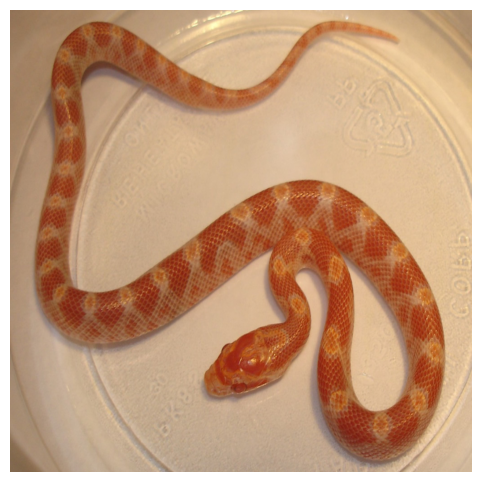

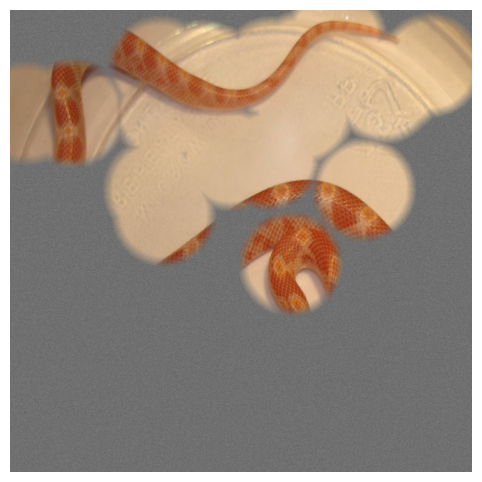

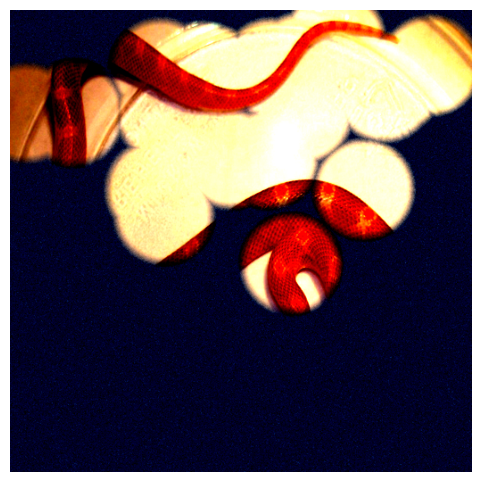

In [21]:
### Example Viz:

from nnet_functions import prepare_model, get_image_repr, pixels_within_radius, reconstruct_image, reconstruct_image_2

m = 1

plt.figure(figsize=(10, 6))
plt.imshow(images_4d[m,:,:,:])
plt.axis('off');

if add_noise:
    if background is None:
        background_used = np.mean(images_4d[m,:,:,:], axis=(0,1));
    else:
        background_used = background
    noise      = np.random.default_rng(1000 + m).normal(0, add_noise, images_4d[m].shape[:2])
    background_used = np.repeat(np.clip(background_used[0] + noise[..., None], background_used[1] + noise[..., None], background_used[2] + noise[..., None]).astype(np.uint8), 3, axis=2)

current_reconstructed_image = reconstruct_image_2(
    images_4d, current_concatenated, current_concatenated_values, image_index=m,
    feather=smooth_radius, background=background_used)

print(f'Rozmiar: {current_reconstructed_image.shape}, typ: {current_reconstructed_image.dtype}')
plt.figure(figsize=(10, 6))
plt.imshow(current_reconstructed_image)
plt.axis('off');

x = tfm(Image.fromarray(current_reconstructed_image)).unsqueeze(0).to(device, non_blocking=True)

plt.figure(figsize=(10, 6))
plt.imshow(np.squeeze(x.detach().cpu()).permute(1, 2, 0).numpy())
plt.axis('off');

([<matplotlib.axis.YTick at 0x154e73f8190>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15'),
  Text(0, 16, '16'),
  Text(0, 17, '17'),
  Text(0, 18, '18'),
  Text(0, 19, '19'),
  Text(0, 20, '20'),
  Text(0, 21, '21'),
  Text(0, 22, '22')])

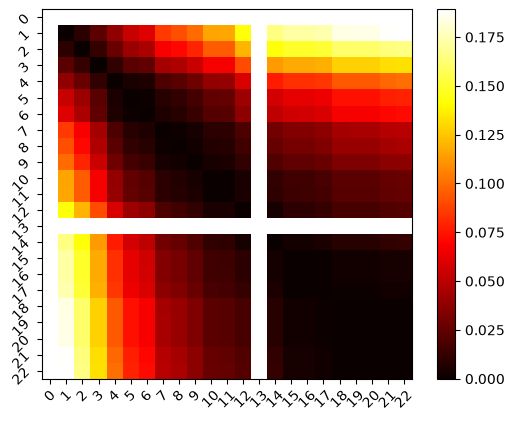

: 

In [ ]:
plt.figure()

plt.imshow(repr_matrix_s[s][im], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(repr_main)), list(repr_main.keys()), rotation=45)
plt.yticks(range(len(repr_main)), list(repr_main.keys()), rotation=45)